DATA GENERATOR

In [ ]:
import pandas as pd

In [29]:
df_1=pd.read_csv("smart_water_minimal_physics_with_sensor_id.csv")

In [13]:
df_1['timestamp'].value_counts()

timestamp
2025-01-01 00:00:00    5
2025-01-01 00:00:05    5
2025-01-01 00:00:10    5
2025-01-01 00:00:15    5
2025-01-01 00:00:20    5
                      ..
2025-01-01 23:59:35    5
2025-01-01 23:59:40    5
2025-01-01 23:59:45    5
2025-01-01 23:59:50    5
2025-01-01 23:59:55    5
Name: count, Length: 17280, dtype: int64

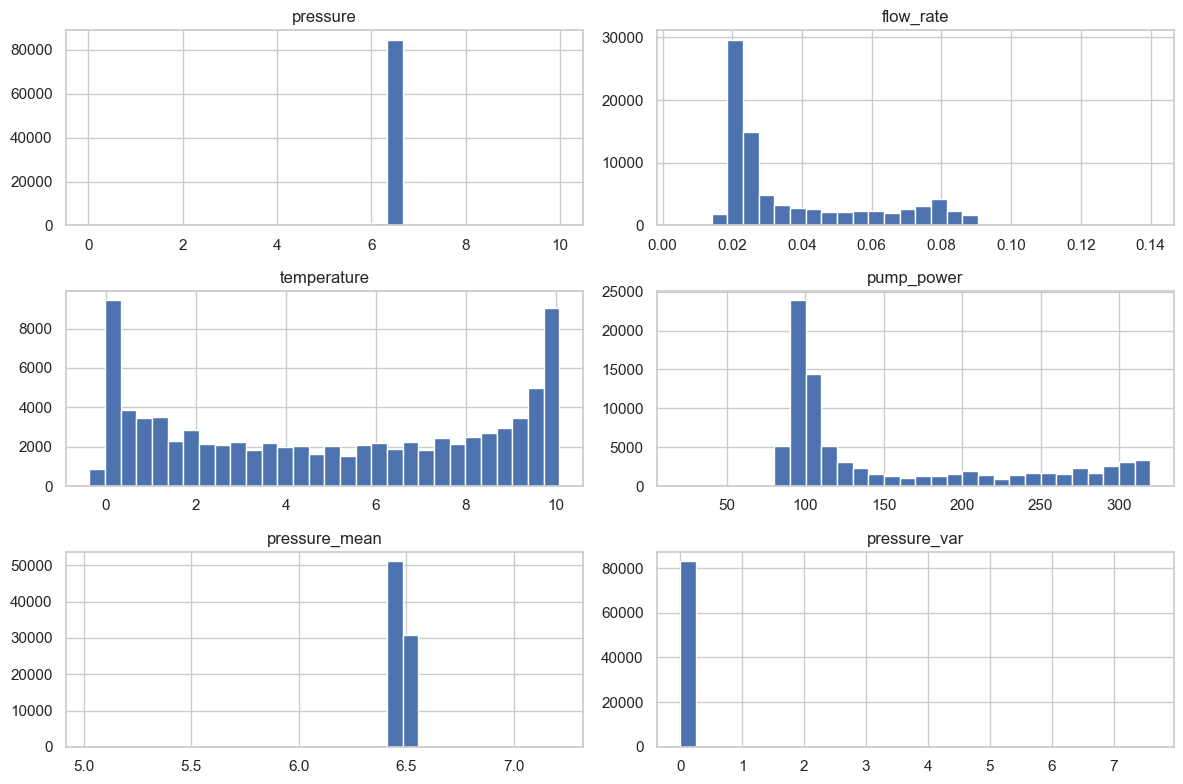

In [14]:
import matplotlib.pyplot as plt
num_cols = ["pressure", "flow_rate", "temperature",
            "pump_power", "pressure_mean", "pressure_var"]

df_1[num_cols].describe().T


df_1[num_cols].hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()


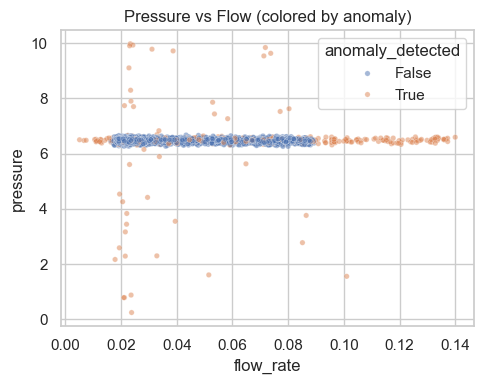

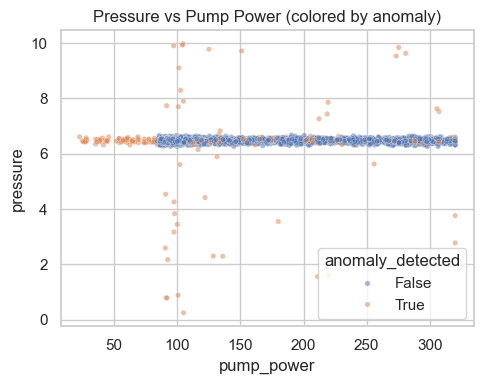

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.scatterplot(
    data=df_1.sample(5000, random_state=0),  # subsample for speed
    x="flow_rate", y="pressure", hue="anomaly_detected",
    alpha=0.5, s=15
)
plt.title("Pressure vs Flow (colored by anomaly)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
sns.scatterplot(
    data=df_1.sample(5000, random_state=0),
    x="pump_power", y="pressure", hue="anomaly_detected",
    alpha=0.5, s=15
)
plt.title("Pressure vs Pump Power (colored by anomaly)")
plt.tight_layout()
plt.show()


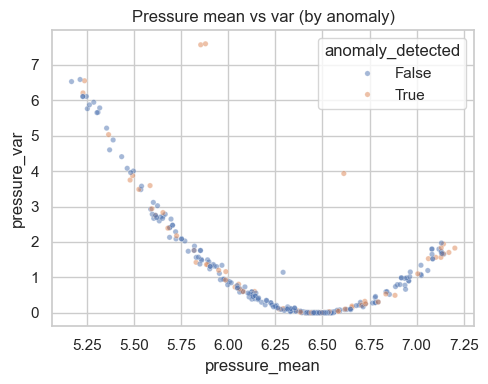

In [16]:
plt.figure(figsize=(5,4))
sns.scatterplot(
    data=df_1.sample(5000, random_state=0),
    x="pressure_mean", y="pressure_var", hue="anomaly_detected",
    alpha=0.5, s=15
)
plt.title("Pressure mean vs var (by anomaly)")
plt.tight_layout()
plt.show()


In [18]:
df_1[num_cols + ["anomaly_detected"]].corr()["anomaly_detected"].sort_values()


pressure           -0.129741
pressure_mean      -0.041974
temperature         0.004000
pump_power          0.026640
pressure_var        0.072047
flow_rate           0.219871
anomaly_detected    1.000000
Name: anomaly_detected, dtype: float64

preprocessing

In [19]:
df_1 = df_1.sort_values(["timestamp", "sensor_id"])
df_1["timestamp"] = pd.to_datetime(df_1["timestamp"])
df_1.set_index("timestamp", inplace=True)



Loaded rows: 86,400
Split counts: {'train': 60480, 'val': 12960, 'test': 12960}
Epoch 01/12 | train_loss=1.0126 | val_loss=1.1195
Epoch 02/12 | train_loss=0.7969 | val_loss=1.0124
Epoch 03/12 | train_loss=0.7331 | val_loss=0.9482
Epoch 04/12 | train_loss=0.6898 | val_loss=0.9095
Epoch 05/12 | train_loss=0.6502 | val_loss=0.8689
Epoch 06/12 | train_loss=0.6143 | val_loss=0.8269
Epoch 07/12 | train_loss=0.5680 | val_loss=0.7643
Epoch 08/12 | train_loss=0.5293 | val_loss=0.7375
Epoch 09/12 | train_loss=0.4924 | val_loss=0.7108
Epoch 10/12 | train_loss=0.4633 | val_loss=0.6783
Epoch 11/12 | train_loss=0.4275 | val_loss=0.6468
Epoch 12/12 | train_loss=0.3983 | val_loss=0.6149

=== Test Metrics ===

LSTM:
{'accuracy': 0.9388, 'precision': 0.7061, 'recall': 0.72, 'f1': 0.713, 'roc_auc': 0.8985}
Confusion matrix:
 [[11182   410]
 [  383   985]]

XGBoost:
{'accuracy': 0.9113, 'precision': 0.5474, 'recall': 0.9247, 'f1': 0.6877, 'roc_auc': 0.974}
Confusion matrix:
 [[10546  1046]
 [  103  1265]]

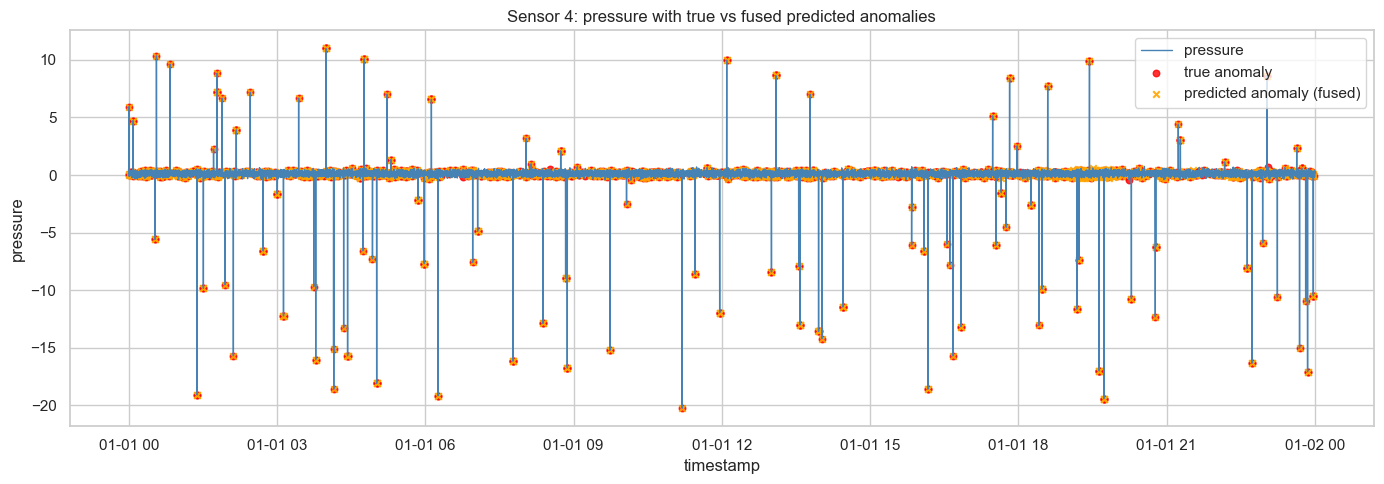

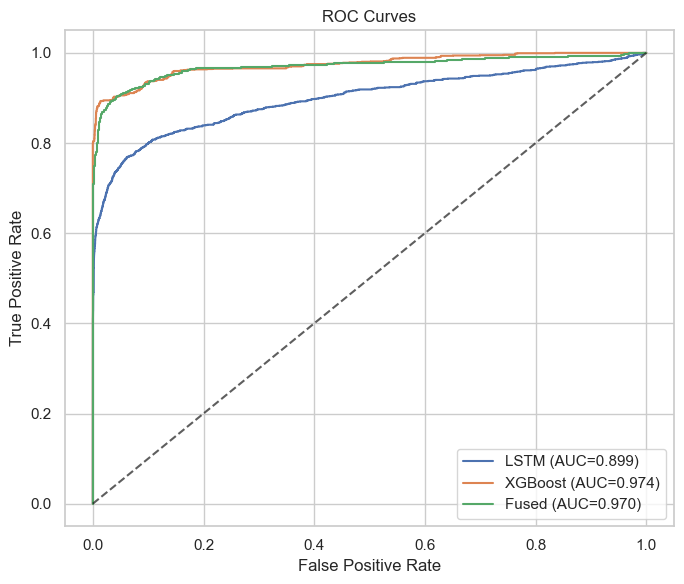

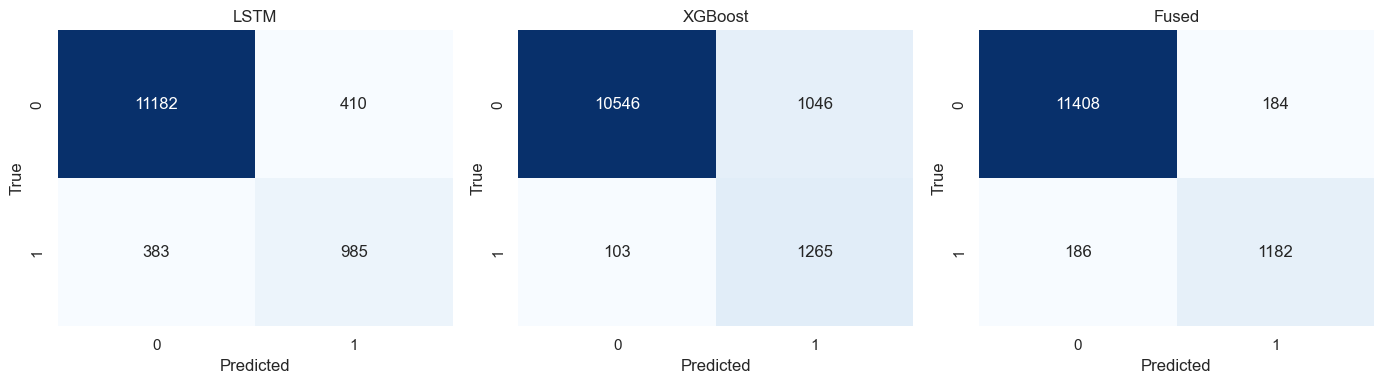

In [ ]:
# End-to-end anomaly detection: LSTM + XGBoost + fusion
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, roc_curve, classification_report
    )

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from xgboost import XGBClassifier

# -------------------------
# Config
# -------------------------
CSV_CANDIDATES = ["smart_water_minimal_physics_with_sensor_id.csv", "smart_water_minimal.csv"]
CSV_PATH = next((p for p in CSV_CANDIDATES if Path(p).exists()), CSV_CANDIDATES[0])
LABEL_COL = "anomaly_detected"
SEQ_LEN = 5
ROLL_WIN = 12
BATCH_SIZE = 256
EPOCHS = 12
LR = 1e-3
THRESH = 0.5
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -------------------------
# Data preparation
# -------------------------
def load_and_prepare(csv_path):
    if not Path(csv_path).exists():
        raise FileNotFoundError(
            f"CSV not found. Tried {CSV_CANDIDATES}. Put your file in the notebook folder or update CSV_PATH."
        )
    df = pd.read_csv(csv_path)

    required = [
        "timestamp", "sensor_id", "pressure", "flow_rate", "temperature",
        "pump_power", "pressure_mean", "pressure_var", LABEL_COL
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()
    df = df.sort_values(["sensor_id", "timestamp"]).reset_index(drop=True)

    df["hour"] = df["timestamp"].dt.hour
    df["dayofweek_idx"] = df["timestamp"].dt.dayofweek
    df["is_weekend"] = (df["dayofweek_idx"] >= 5).astype(int)

    numeric_cols = ["pressure", "flow_rate", "temperature", "pump_power", "pressure_mean", "pressure_var"]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col] = df.groupby("sensor_id")[col].transform(lambda s: s.ffill().bfill())
        df[col] = df[col].fillna(df[col].median())

    df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").fillna(0).astype(int)
    df[LABEL_COL] = (df[LABEL_COL] > 0).astype(int)

    for base in ["pressure", "flow_rate", "pump_power"]:
        df[f"{base}_roll_mean"] = df.groupby("sensor_id")[base].transform(
            lambda s: s.rolling(ROLL_WIN, min_periods=1).mean()
        )
        df[f"{base}_roll_std"] = df.groupby("sensor_id")[base].transform(
            lambda s: s.rolling(ROLL_WIN, min_periods=1).std().fillna(0.0)
        )

    t1 = df["timestamp"].quantile(0.70)
    t2 = df["timestamp"].quantile(0.85)
    df["split"] = np.where(df["timestamp"] <= t1, "train", np.where(df["timestamp"] <= t2, "val", "test"))
    return df

# -------------------------
# LSTM utilities
# -------------------------
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMClassifier(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden_size, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        logits = self.fc(self.dropout(last_hidden)).squeeze(1)
        return logits

def build_lstm_sequences(df, feature_cols, seq_len=5):
    X_list, y_list, end_row_idx = [], [], []
    for _, g in df.groupby("sensor_id", sort=False):
        g = g.sort_values("timestamp")
        Xg = g[feature_cols].values
        yg = g[LABEL_COL].values
        idxg = g.index.values
        if len(g) < seq_len:
            continue
        for end in range(seq_len - 1, len(g)):
            start = end - seq_len + 1
            X_list.append(Xg[start:end + 1])
            y_list.append(yg[end])
            end_row_idx.append(idxg[end])

    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32), np.array(end_row_idx, dtype=np.int64)

def train_lstm_model(model, train_loader, val_loader, epochs=10, lr=1e-3):
    pos = 0
    total = 0
    for _, yb in train_loader:
        pos += yb.sum().item()
        total += len(yb)
    neg = max(total - pos, 1.0)
    pos = max(pos, 1.0)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([neg / pos], device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(xb)
        train_loss /= max(len(train_loader.dataset), 1)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                val_loss += criterion(logits, yb).item() * len(xb)
        val_loss /= max(len(val_loader.dataset), 1)

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

def predict_lstm_proba(model, X, batch_size=1024):
    model.eval()
    probs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(X[i:i + batch_size], dtype=torch.float32, device=DEVICE)
            probs.append(torch.sigmoid(model(xb)).cpu().numpy())
    return np.concatenate(probs, axis=0)

def evaluate_binary(y_true, p_pred, threshold=0.5):
    y_hat = (p_pred >= threshold).astype(int)
    out = {
        "accuracy": accuracy_score(y_true, y_hat),
        "precision": precision_score(y_true, y_hat, zero_division=0),
        "recall": recall_score(y_true, y_hat, zero_division=0),
        "f1": f1_score(y_true, y_hat, zero_division=0),
    }
    try:
        out["roc_auc"] = roc_auc_score(y_true, p_pred)
    except ValueError:
        out["roc_auc"] = np.nan
    out["cm"] = confusion_matrix(y_true, y_hat)
    return out

# -------------------------
# Main pipeline
# -------------------------
df_model = load_and_prepare(CSV_PATH)
print(f"Loaded rows: {len(df_model):,}")
print("Split counts:", df_model["split"].value_counts().to_dict())

lstm_features = ["pressure", "flow_rate", "temperature", "pump_power", "pressure_mean", "pressure_var"]
scaler_lstm = StandardScaler()
df_model.loc[:, lstm_features] = scaler_lstm.fit_transform(df_model[lstm_features])

X_seq, y_seq, seq_row_idx = build_lstm_sequences(df_model, lstm_features, seq_len=SEQ_LEN)
seq_splits = df_model.loc[seq_row_idx, "split"].values

train_idx = np.where(seq_splits == "train")[0]
val_idx = np.where(seq_splits == "val")[0]
test_idx = np.where(seq_splits == "test")[0]

X_tr_lstm, y_tr_lstm = X_seq[train_idx], y_seq[train_idx]
X_val_lstm, y_val_lstm = X_seq[val_idx], y_seq[val_idx]

train_loader = DataLoader(SeqDataset(X_tr_lstm, y_tr_lstm), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(SeqDataset(X_val_lstm, y_val_lstm), batch_size=BATCH_SIZE, shuffle=False)

model = LSTMClassifier(n_features=len(lstm_features), hidden_size=64, num_layers=1, dropout=0.2).to(DEVICE)
train_lstm_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR)

p_lstm_all_seq = predict_lstm_proba(model, X_seq)
df_model["p_lstm"] = np.nan
df_model.loc[seq_row_idx, "p_lstm"] = p_lstm_all_seq

xgb_features = [
    "pressure", "flow_rate", "temperature", "pump_power",
    "pressure_mean", "pressure_var",
    "hour", "dayofweek_idx", "is_weekend",
    "pressure_roll_mean", "pressure_roll_std",
    "flow_rate_roll_mean", "flow_rate_roll_std",
    "pump_power_roll_mean", "pump_power_roll_std",
    ]

X_xgb = df_model[xgb_features].values
y_xgb = df_model[LABEL_COL].values

train_mask = (df_model["split"] == "train").values
val_mask = (df_model["split"] == "val").values
test_mask = (df_model["split"] == "test").values

X_tr_xgb, y_tr_xgb = X_xgb[train_mask], y_xgb[train_mask]
X_val_xgb, y_val_xgb = X_xgb[val_mask], y_xgb[val_mask]

pos = y_tr_xgb.sum()
neg = len(y_tr_xgb) - pos
scale_pos_weight = neg / max(pos, 1)

xgb_model = XGBClassifier(
    n_estimators=250, max_depth=5, learning_rate=0.05,
    subsample=0.9, colsample_bytree=0.9, objective="binary:logistic",
    eval_metric="logloss", random_state=RANDOM_STATE,
    scale_pos_weight=scale_pos_weight, n_jobs=-1
    )
xgb_model.fit(X_tr_xgb, y_tr_xgb, eval_set=[(X_val_xgb, y_val_xgb)], verbose=False)

df_model["p_xgb"] = xgb_model.predict_proba(X_xgb)[:, 1]

df_model["p_lstm_aligned"] = df_model["p_lstm"].fillna(df_model["p_xgb"])
df_model["p_final"] = 0.5 * df_model["p_lstm_aligned"] + 0.5 * df_model["p_xgb"]

y_test = df_model.loc[test_mask, LABEL_COL].values
p_xgb_test = df_model.loc[test_mask, "p_xgb"].values
p_final_test = df_model.loc[test_mask, "p_final"].values

lstm_valid_mask = test_mask & df_model["p_lstm"].notna().values
y_test_lstm = df_model.loc[lstm_valid_mask, LABEL_COL].values
p_lstm_test = df_model.loc[lstm_valid_mask, "p_lstm"].values

m_lstm = evaluate_binary(y_test_lstm, p_lstm_test, threshold=THRESH)
m_xgb = evaluate_binary(y_test, p_xgb_test, threshold=THRESH)
m_fused = evaluate_binary(y_test, p_final_test, threshold=THRESH)

print("\n=== Test Metrics ===")
for name, m in [("LSTM", m_lstm), ("XGBoost", m_xgb), ("Fused", m_fused)]:
    print(f"\n{name}:")
    print({k: round(v, 4) if isinstance(v, float) else v for k, v in m.items() if k != "cm"})
    print("Confusion matrix:\n", m["cm"])

print("\nClassification report (Fused):")
print(classification_report(y_test, (p_final_test >= THRESH).astype(int), zero_division=0))

# -------------------------
# Visualizations
# -------------------------
sns.set(style="whitegrid")

sensor_anom_counts = df_model.groupby("sensor_id")[LABEL_COL].sum().sort_values(ascending=False)
sensor_to_plot = sensor_anom_counts.index[0]
plot_df = df_model[df_model["sensor_id"] == sensor_to_plot].copy()
plot_df["pred_final"] = (plot_df["p_final"] >= THRESH).astype(int)

plt.figure(figsize=(14, 5))
plt.plot(plot_df["timestamp"], plot_df["pressure"], label="pressure", color="steelblue", linewidth=1)
true_anom = plot_df[plot_df[LABEL_COL] == 1]
pred_anom = plot_df[plot_df["pred_final"] == 1]
plt.scatter(true_anom["timestamp"], true_anom["pressure"], color="red", s=22, label="true anomaly", alpha=0.8)
plt.scatter(pred_anom["timestamp"], pred_anom["pressure"], color="orange", s=22, marker="x", label="predicted anomaly (fused)", alpha=0.9)
plt.title(f"Sensor {sensor_to_plot}: pressure with true vs fused predicted anomalies")
plt.xlabel("timestamp")
plt.ylabel("pressure")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
if len(np.unique(y_test_lstm)) > 1:
    fpr_l, tpr_l, _ = roc_curve(y_test_lstm, p_lstm_test)
    plt.plot(fpr_l, tpr_l, label=f"LSTM (AUC={m_lstm['roc_auc']:.3f})")
if len(np.unique(y_test)) > 1:
    fpr_x, tpr_x, _ = roc_curve(y_test, p_xgb_test)
    fpr_f, tpr_f, _ = roc_curve(y_test, p_final_test)
    plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC={m_xgb['roc_auc']:.3f})")
    plt.plot(fpr_f, tpr_f, label=f"Fused (AUC={m_fused['roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, cm) in zip(axes, [("LSTM", m_lstm["cm"]), ("XGBoost", m_xgb["cm"]), ("Fused", m_fused["cm"])]):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
plt.tight_layout()
plt.show()

X_frames shape: (17280, 5, 6)
y_frames shape: (17280,)
Frame anomaly rate: 0.1501736111111111
X_lstm shape: (17231, 50, 30) input_dim: 30
y_lstm shape: (17231,)
Train sequences: (13784, 50, 30) Val sequences: (3447, 50, 30)
Epoch 01/12 | train_loss=0.9153 | val_acc=0.8973 | val_prec=0.7756 | val_rec=0.4601 | val_f1=0.5776
Epoch 02/12 | train_loss=0.7419 | val_acc=0.9362 | val_prec=0.9203 | val_rec=0.6369 | val_f1=0.7528
Epoch 03/12 | train_loss=0.6070 | val_acc=0.9495 | val_prec=0.9656 | val_rec=0.6939 | val_f1=0.8075
Epoch 04/12 | train_loss=0.5366 | val_acc=0.9617 | val_prec=0.9713 | val_rec=0.7719 | val_f1=0.8602
Epoch 05/12 | train_loss=0.4829 | val_acc=0.9661 | val_prec=0.9881 | val_rec=0.7871 | val_f1=0.8762
Epoch 06/12 | train_loss=0.4322 | val_acc=0.9695 | val_prec=0.9884 | val_rec=0.8099 | val_f1=0.8903
Epoch 07/12 | train_loss=0.3982 | val_acc=0.9704 | val_prec=0.9711 | val_rec=0.8308 | val_f1=0.8955
Epoch 08/12 | train_loss=0.3731 | val_acc=0.9669 | val_prec=0.9239 | val_rec

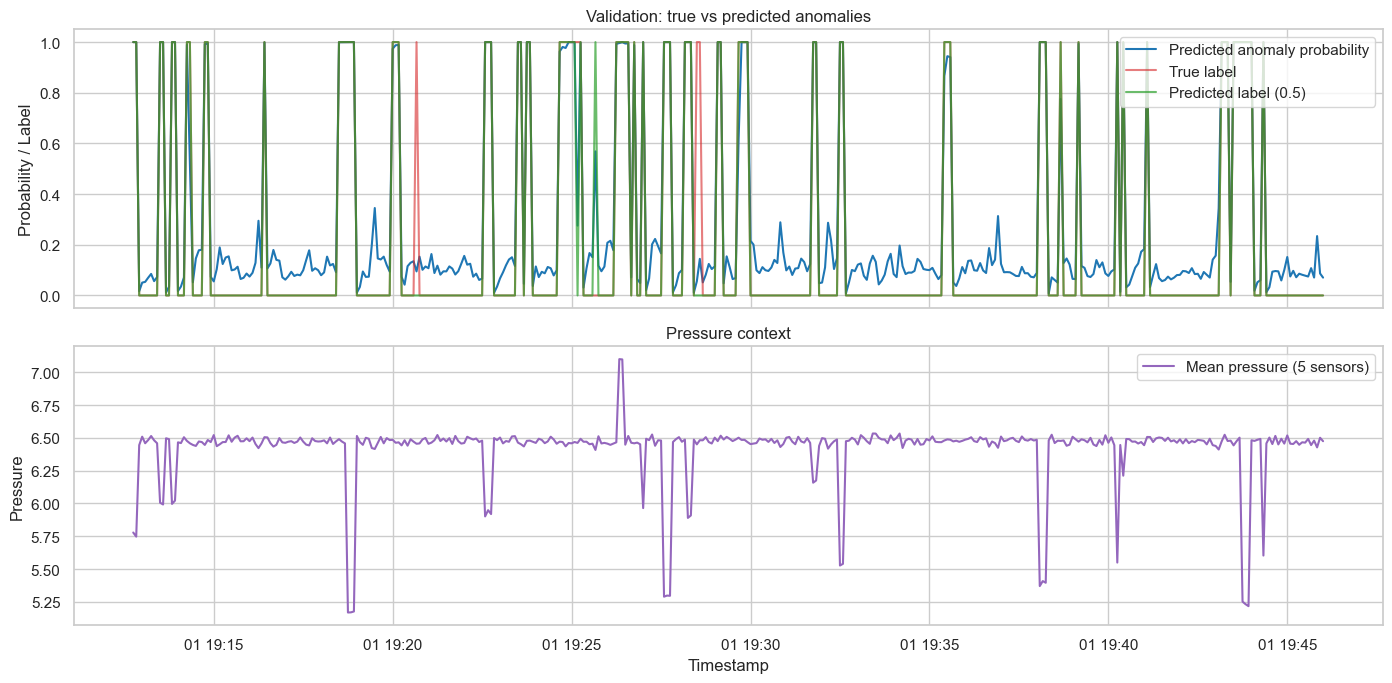

In [ ]:
# Frame-based LSTM anomaly detection (5 sensors per timestamp)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    )

# -------------------------
# Config
# -------------------------
CSV_PATH = "smart_water_minimal_physics_with_sensor_id.csv"
FEATURE_COLS = ["pressure", "flow_rate", "temperature", "pump_power", "pressure_mean", "pressure_var"]
LABEL_COL = "anomaly_detected"
EXPECTED_SENSORS = [1, 2, 3, 4, 5]
SEQ_LEN = 5
BATCH_SIZE = 64
EPOCHS = 12
LR = 1e-3
THRESH = 0.5
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -------------------------
# 1) Load & preprocess
# -------------------------
df = pd.read_csv(CSV_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).copy()
df = df.sort_values(["timestamp", "sensor_id"]).reset_index(drop=True)

# Ensure required columns exist
required_cols = ["timestamp", "sensor_id", *FEATURE_COLS, LABEL_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Numeric conversion + fill
for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df.groupby("sensor_id")[col].transform(lambda s: s.ffill().bfill())
    df[col] = df[col].fillna(df[col].median())

df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").fillna(0).astype(int)
df[LABEL_COL] = (df[LABEL_COL] > 0).astype(int)

# Verify exactly 5 sensors per timestamp and ids are 1..5
counts = df.groupby("timestamp")["sensor_id"].nunique()
bad_counts = counts[counts != len(EXPECTED_SENSORS)]
if len(bad_counts) > 0:
    raise ValueError(
        f"Found {len(bad_counts)} timestamps without exactly {len(EXPECTED_SENSORS)} sensors. Example: {bad_counts.head().to_dict()}"
    )

sensor_sets_ok = df.groupby("timestamp")["sensor_id"].apply(
    lambda s: set(s.tolist()) == set(EXPECTED_SENSORS)
    )
if not sensor_sets_ok.all():
    bad_ts = sensor_sets_ok[~sensor_sets_ok].index[:5].tolist()
    raise ValueError(f"Some timestamps do not contain sensor ids {EXPECTED_SENSORS}. Examples: {bad_ts}")

# -------------------------
# 2) Build frames: (N_times, 5, n_features)
# -------------------------
grp = df.groupby("timestamp", sort=True)
n_times = grp.ngroups
n_features = len(FEATURE_COLS)

X_frames = np.zeros((n_times, len(EXPECTED_SENSORS), n_features), dtype=np.float32)
y_frames = np.zeros(n_times, dtype=np.int64)
frame_times = []

for i, (ts, g) in enumerate(grp):
    g = g.sort_values("sensor_id")
    X_frames[i] = g[FEATURE_COLS].values.astype(np.float32)
    y_frames[i] = int(g[LABEL_COL].max())  # frame anomaly if any of 5 sensors anomalous
    frame_times.append(ts)

frame_times = np.array(frame_times)
print("X_frames shape:", X_frames.shape)
print("y_frames shape:", y_frames.shape)
print("Frame anomaly rate:", y_frames.mean())

# Standardize by fitting on training-time frames only
split_idx = int(0.8 * n_times)
scaler = StandardScaler()
X_train_flat = X_frames[:split_idx].reshape(-1, n_features)
scaler.fit(X_train_flat)

X_frames_scaled = scaler.transform(X_frames.reshape(-1, n_features)).reshape(X_frames.shape).astype(np.float32)

# -------------------------
# 3) Build LSTM sequences
# -------------------------
def build_sequences(Xf, yf, times, seq_len=5):
    X_seq, y_seq, t_seq = [], [], []
    for i in range(0, len(Xf) - seq_len + 1):
        window = Xf[i:i + seq_len]                        # (seq_len, 5, n_features)
        label = yf[i + seq_len - 1]                      # last frame label
        t_last = times[i + seq_len - 1]

        window_flat = window.reshape(seq_len, -1)        # (seq_len, 5*n_features)
        X_seq.append(window_flat)
        y_seq.append(label)
        t_seq.append(t_last)

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32), np.array(t_seq)

X_lstm, y_lstm, seq_times = build_sequences(X_frames_scaled, y_frames, frame_times, seq_len=SEQ_LEN)
input_dim = X_lstm.shape[-1]
print("X_lstm shape:", X_lstm.shape, "input_dim:", input_dim)
print("y_lstm shape:", y_lstm.shape)

# Time-respecting split on sequences (earliest 80% train, latest 20% val)
n_seq = len(X_lstm)
split_seq = int(0.8 * n_seq)

X_train, y_train = X_lstm[:split_seq], y_lstm[:split_seq]
X_val, y_val = X_lstm[split_seq:], y_lstm[split_seq:]
t_val = seq_times[split_seq:]

print("Train sequences:", X_train.shape, "Val sequences:", X_val.shape)

# -------------------------
# 4) PyTorch dataset/model
# -------------------------
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMAnomalyClassifier(nn.Module):
    def __init__(self, input_dim, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_h = out[:, -1, :]
        logits = self.fc(self.dropout(last_h)).squeeze(1)
        return logits

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(SeqDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)

model = LSTMAnomalyClassifier(input_dim=input_dim, hidden_size=64, num_layers=1, dropout=0.2).to(DEVICE)

# Handle class imbalance using pos_weight
pos = y_train.sum()
neg = len(y_train) - pos
pos_weight = torch.tensor([neg / max(pos, 1.0)], dtype=torch.float32, device=DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# -------------------------
# 5) Train + validate
# -------------------------
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "cm": confusion_matrix(y_true, y_pred),
    }
    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except ValueError:
        metrics["roc_auc"] = np.nan
    return metrics

def predict_probs(model, loader):
    model.eval()
    all_probs, all_y = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.append(probs)
            all_y.append(yb.numpy())
    return np.concatenate(all_y), np.concatenate(all_probs)

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(xb)

    train_loss = total_loss / len(train_loader.dataset)

    y_val_true, p_val = predict_probs(model, val_loader)
    m = compute_metrics(y_val_true.astype(int), p_val, threshold=THRESH)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | "
        f"val_acc={m['accuracy']:.4f} | val_prec={m['precision']:.4f} | "
        f"val_rec={m['recall']:.4f} | val_f1={m['f1']:.4f}"
    )

# -------------------------
# 6) Final evaluation
# -------------------------
y_val_true, p_val = predict_probs(model, val_loader)
metrics = compute_metrics(y_val_true.astype(int), p_val, threshold=THRESH)
y_val_pred = (p_val >= THRESH).astype(int)

print("\n=== Validation results ===")
print("Confusion matrix:\n", metrics["cm"])
print(
    {k: round(v, 4) if isinstance(v, float) else v
     for k, v in metrics.items() if k != "cm"}
    )

# -------------------------
# 7) Visualization
# -------------------------
# Plot on a chosen validation range
plot_n = min(400, len(y_val_true))
plot_slice = slice(0, plot_n)

times_plot = pd.to_datetime(t_val[plot_slice])
y_true_plot = y_val_true[plot_slice]
y_pred_plot = y_val_pred[plot_slice]
p_plot = p_val[plot_slice]

# Optional overlay: mean pressure across 5 sensors at frame level
pressure_idx = FEATURE_COLS.index("pressure")
frame_pressure_mean = X_frames[:, :, pressure_idx].mean(axis=1)
pressure_series = pd.Series(frame_pressure_mean, index=frame_times)
pressure_plot = pressure_series.loc[times_plot].values

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(times_plot, p_plot, label="Predicted anomaly probability", color="tab:blue")
axes[0].plot(times_plot, y_true_plot, label="True label", color="tab:red", alpha=0.6)
axes[0].plot(times_plot, y_pred_plot, label="Predicted label (0.5)", color="tab:green", alpha=0.7)
axes[0].set_ylabel("Probability / Label")
axes[0].set_title("Validation: true vs predicted anomalies")
axes[0].legend(loc="upper right")

axes[1].plot(times_plot, pressure_plot, label="Mean pressure (5 sensors)", color="tab:purple")
axes[1].set_ylabel("Pressure")
axes[1].set_xlabel("Timestamp")
axes[1].set_title("Pressure context")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

In [ ]:
# Retrain with more epochs + early stopping
# Frame-based LSTM anomaly detection (5 sensors per timestamp)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
    )

# -------------------------
# Config
# -------------------------
CSV_PATH = "smart_water_minimal_physics_with_sensor_id.csv"
FEATURE_COLS = ["pressure", "flow_rate", "temperature", "pump_power", "pressure_mean", "pressure_var"]
LABEL_COL = "anomaly_detected"
EXPECTED_SENSORS = [1, 2, 3, 4, 5]
SEQ_LEN = 5
BATCH_SIZE = 64
EPOCHS = 12
LR = 1e-3
THRESH = 0.5
RANDOM_STATE = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# -------------------------
# 1) Load & preprocess
# -------------------------
df = pd.read_csv(CSV_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).copy()
df = df.sort_values(["timestamp", "sensor_id"]).reset_index(drop=True)

# Ensure required columns exist
required_cols = ["timestamp", "sensor_id", *FEATURE_COLS, LABEL_COL]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

# Numeric conversion + fill
for col in FEATURE_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    df[col] = df.groupby("sensor_id")[col].transform(lambda s: s.ffill().bfill())
    df[col] = df[col].fillna(df[col].median())

df[LABEL_COL] = pd.to_numeric(df[LABEL_COL], errors="coerce").fillna(0).astype(int)
df[LABEL_COL] = (df[LABEL_COL] > 0).astype(int)

# Verify exactly 5 sensors per timestamp and ids are 1..5
counts = df.groupby("timestamp")["sensor_id"].nunique()
bad_counts = counts[counts != len(EXPECTED_SENSORS)]
if len(bad_counts) > 0:
    raise ValueError(
        f"Found {len(bad_counts)} timestamps without exactly {len(EXPECTED_SENSORS)} sensors. Example: {bad_counts.head().to_dict()}"
    )

sensor_sets_ok = df.groupby("timestamp")["sensor_id"].apply(
    lambda s: set(s.tolist()) == set(EXPECTED_SENSORS)
    )
if not sensor_sets_ok.all():
    bad_ts = sensor_sets_ok[~sensor_sets_ok].index[:5].tolist()
    raise ValueError(f"Some timestamps do not contain sensor ids {EXPECTED_SENSORS}. Examples: {bad_ts}")

# -------------------------
# 2) Build frames: (N_times, 5, n_features)
# -------------------------
grp = df.groupby("timestamp", sort=True)
n_times = grp.ngroups
n_features = len(FEATURE_COLS)

X_frames = np.zeros((n_times, len(EXPECTED_SENSORS), n_features), dtype=np.float32)
y_frames = np.zeros(n_times, dtype=np.int64)
frame_times = []

for i, (ts, g) in enumerate(grp):
    g = g.sort_values("sensor_id")
    X_frames[i] = g[FEATURE_COLS].values.astype(np.float32)
    y_frames[i] = int(g[LABEL_COL].max())  # frame anomaly if any of 5 sensors anomalous
    frame_times.append(ts)

frame_times = np.array(frame_times)
print("X_frames shape:", X_frames.shape)
print("y_frames shape:", y_frames.shape)
print("Frame anomaly rate:", y_frames.mean())

# Standardize by fitting on training-time frames only
split_idx = int(0.8 * n_times)
scaler = StandardScaler()
X_train_flat = X_frames[:split_idx].reshape(-1, n_features)
scaler.fit(X_train_flat)

X_frames_scaled = scaler.transform(X_frames.reshape(-1, n_features)).reshape(X_frames.shape).astype(np.float32)

# -------------------------
# 3) Build LSTM sequences
# -------------------------
def build_sequences(Xf, yf, times, seq_len=5):
    X_seq, y_seq, t_seq = [], [], []
    for i in range(0, len(Xf) - seq_len + 1):
        window = Xf[i:i + seq_len]                        # (seq_len, 5, n_features)
        label = yf[i + seq_len - 1]                      # last frame label
        t_last = times[i + seq_len - 1]

        window_flat = window.reshape(seq_len, -1)        # (seq_len, 5*n_features)
        X_seq.append(window_flat)
        y_seq.append(label)
        t_seq.append(t_last)

    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32), np.array(t_seq)

X_lstm, y_lstm, seq_times = build_sequences(X_frames_scaled, y_frames, frame_times, seq_len=SEQ_LEN)
input_dim = X_lstm.shape[-1]
print("X_lstm shape:", X_lstm.shape, "input_dim:", input_dim)
print("y_lstm shape:", y_lstm.shape)

# Time-respecting split on sequences (earliest 80% train, latest 20% val)
n_seq = len(X_lstm)
split_seq = int(0.8 * n_seq)

X_train, y_train = X_lstm[:split_seq], y_lstm[:split_seq]
X_val, y_val = X_lstm[split_seq:], y_lstm[split_seq:]
t_val = seq_times[split_seq:]

print("Train sequences:", X_train.shape, "Val sequences:", X_val.shape)

# -------------------------
# 4) PyTorch dataset/model
# -------------------------
class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class LSTMAnomalyClassifier(nn.Module):
    def __init__(self, input_dim, hidden_size=64, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last_h = out[:, -1, :]
        logits = self.fc(self.dropout(last_h)).squeeze(1)
        return logits

train_loader = DataLoader(SeqDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(SeqDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)




import copy

EPOCHS = 10
PATIENCE = 8
MIN_DELTA = 1e-4

model_es = LSTMAnomalyModel(input_dim=input_dim, hidden_size=64, num_layers=1, dropout=0.2).to(DEVICE)
optimizer_es = torch.optim.Adam(model_es.parameters(), lr=LR)
criterion_es = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

best_val_loss = np.inf
best_state = None
best_epoch = 0
wait = 0

for epoch in range(1, EPOCHS + 1):
    model_es.train()
    train_running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer_es.zero_grad()
        logits = model_es(xb)
        loss = criterion_es(logits, yb)
        loss.backward()
        optimizer_es.step()
        train_running_loss += loss.item() * len(xb)

    train_loss = train_running_loss / len(train_loader.dataset)

    model_es.eval()
    val_running_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model_es(xb)
            vloss = criterion_es(logits, yb)
            val_running_loss += vloss.item() * len(xb)
    val_loss = val_running_loss / len(val_loader.dataset)

    y_val_true, p_val = predict_probabilities(model_es, val_loader)
    met = evaluate_probs(y_val_true.astype(int), p_val, THRESH)

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_acc={met['accuracy']:.4f} | val_prec={met['precision']:.4f} | "
        f"val_rec={met['recall']:.4f} | val_f1={met['f1']:.4f}"
    )

    if val_loss < (best_val_loss - MIN_DELTA):
        best_val_loss = val_loss
        best_state = copy.deepcopy(model_es.state_dict())
        best_epoch = epoch
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch}. Best epoch: {best_epoch} (val_loss={best_val_loss:.4f})")
            break

if best_state is not None:
    model_es.load_state_dict(best_state)

y_val_true, p_val = predict_probabilities(model_es, val_loader)
y_val_pred = (p_val >= THRESH).astype(int)
final_metrics_es = evaluate_probs(y_val_true.astype(int), p_val, THRESH)

print("\n=== Final Validation Metrics (Early Stopping Model) ===")
print(f"Best epoch: {best_epoch} | Best val_loss: {best_val_loss:.4f}")
print("Confusion matrix:\n", final_metrics_es["cm"])
print(
    {k: round(v, 4) if isinstance(v, float) else v
     for k, v in final_metrics_es.items() if k != "cm"}
    )

Epoch 01/10 | train_loss=0.9495 | val_loss=0.9297 | val_acc=0.9129 | val_prec=0.8247 | val_rec=0.5446 | val_f1=0.6560
Epoch 02/10 | train_loss=0.6722 | val_loss=0.7002 | val_acc=0.9459 | val_prec=0.9381 | val_rec=0.6907 | val_f1=0.7956
Epoch 03/10 | train_loss=0.5440 | val_loss=0.5616 | val_acc=0.9572 | val_prec=0.9417 | val_rec=0.7666 | val_f1=0.8452
Epoch 04/10 | train_loss=0.4676 | val_loss=0.4834 | val_acc=0.9656 | val_prec=0.9636 | val_rec=0.8046 | val_f1=0.8769
Epoch 05/10 | train_loss=0.4171 | val_loss=0.4244 | val_acc=0.9664 | val_prec=0.9400 | val_rec=0.8330 | val_f1=0.8833
Epoch 06/10 | train_loss=0.3872 | val_loss=0.4220 | val_acc=0.9378 | val_prec=0.7549 | val_rec=0.8767 | val_f1=0.8112
Epoch 07/10 | train_loss=0.3563 | val_loss=0.3954 | val_acc=0.9601 | val_prec=0.8595 | val_rec=0.8824 | val_f1=0.8708
Epoch 08/10 | train_loss=0.3371 | val_loss=0.3864 | val_acc=0.9569 | val_prec=0.8327 | val_rec=0.8975 | val_f1=0.8639
Epoch 09/10 | train_loss=0.3175 | val_loss=0.3701 | val_